# Goodreads Reading Analysis
This project explores reading habits and trends from my Goodreads library export using Python, Pandas, and Matplotlib.

# Imports
Import libraries used for analysis and visualisation.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_rows', None)

# Load Data

In [18]:
df = pd.read_csv('goodreads_library_export.csv') #loading CSV file
title = df['Title']
shelf = df['Exclusive Shelf']
dateread = df['Date Read']

# Data Validation

In [19]:
shelf_counts = shelf.value_counts()
# print(shelf_counts)
# print(len(df))
# print(df['Title'].duplicated().sum())
duplicates =df[title.duplicated(keep=False)]
# print(duplicates[['Title', 'Author','Date Read']])
# print(df.isnull().sum())

# print((shelf == 'read')  & (dateread.isnull()))
# print(((shelf == 'read')  & (dateread.isnull())).sum()) #All books marked as "read" have a Date Read.
# print(dateread.isnull().sum())
# print(shelf[dateread.isnull()].value_counts())

# Data Preparation

In [20]:
readbooks = df[shelf=='read']
# print(len(readbooks))
# print(readbooks[['Title','Exclusive Shelf']])

# print(readbooks.columns.tolist()) #check colums to work with
#We'll use 'Title, 'Author', My Rating, Number of Pages, Year Published, Date Read, Date Added, Read Count

# print((readbooks['My Rating']==0).sum()) #there are 4 unrated books, im excluding those for a cleaner stats
ratedbooks =readbooks[readbooks['My Rating']>0]
# print (len(ratedbooks))
# print(ratedbooks['My Rating'].value_counts().sort_index())
# print(ratedbooks['My Rating'].mean())
#print(readbooks['Date Read'].head()) #want to convert this from plain strings to actual dates value
readbooks = readbooks.copy()
readbooks['Date Read'] = pd.to_datetime(readbooks['Date Read'])
readbooks['Year Read'] = readbooks['Date Read'].dt.year
readbooks['Month Read'] = readbooks['Date Read'].dt.month

# General Reading Statistics
Summary statistics including books read, average rating, average pages per book, and notable books.

In [21]:
print(f"Books read: {(shelf=='read').sum()}")

#Average Rating
print(f"Average Rating: {round(ratedbooks['My Rating'].mean(),2)}"
      f" ({(readbooks['My Rating'] == 0).sum()} unrated books)")


#Average pages per book
avg_pages=readbooks['Number of Pages'].mean()
print("Average pages per book:",round(avg_pages,1))
#Longest and shortest book read
pages_sorted = readbooks[['Number of Pages','Title','Date Read']].sort_values(by='Number of Pages')
# print(longest_book)
shortest=pages_sorted.iloc[0]
longest=pages_sorted.iloc[-1]
print("Longest book read:", longest['Title'], f"({longest['Number of Pages']} pages)")

print(f"Shortest book read: {shortest['Title']}"
    f" ({shortest['Number of Pages']} pages)")


Books read: 58
Average Rating: 4.04 (4 unrated books)
Average pages per book: 249.9
Longest book read: Dune (Dune #1) (704 pages)
Shortest book read: The Communist Manifesto (50 pages)


# Books Read Per Year
Analyse reading volume across 2024 to 2026.

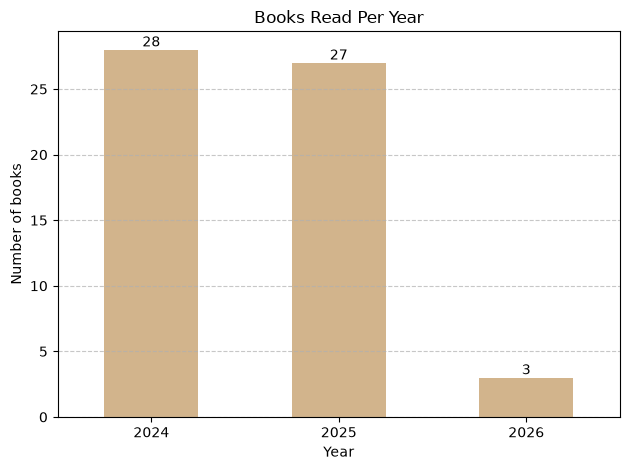

<Figure size 640x480 with 0 Axes>

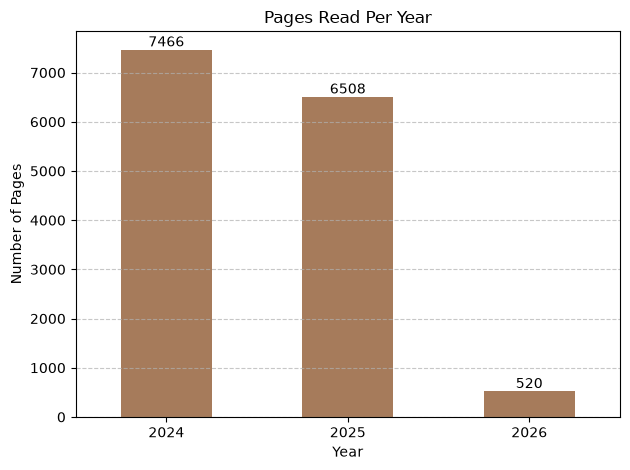

In [22]:
books_per_year = readbooks['Year Read'].value_counts().sort_index()
#books_per_month = readbooks['Month Read'].value_counts().sort_index()
#print(books_per_year)
#print(books_per_month)

#Books per year chart
plt.figure()
ax = books_per_year.plot(kind='bar', color ='tan')
ax.bar_label(ax.containers[0])


plt.title('Books Read Per Year')
plt.xlabel('Year')
plt.ylabel('Number of books')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='dashed', alpha=0.7)
plt.tight_layout()
plt.savefig('Images/books_per_year.png')
#plt.show()

#pages read per year
pages_per_year = readbooks[['Year Read','Number of Pages']].groupby('Year Read').sum()
#print(pages_per_year)

plt.figure()
ax = pages_per_year.plot(kind='bar', color ='#A67B5B', legend = False)
ax.bar_label(ax.containers[0])

plt.title('Pages Read Per Year')
plt.xlabel('Year')
plt.ylabel('Number of Pages')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='dashed', alpha=0.7)
plt.tight_layout()
plt.savefig('Images/pages_per_year.png')



# Books Read Per Month
Analyse monthly reading patterns within each year.

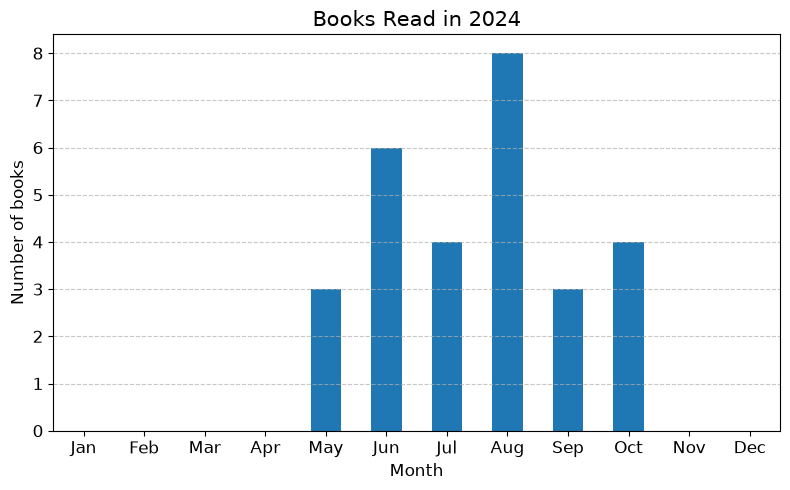

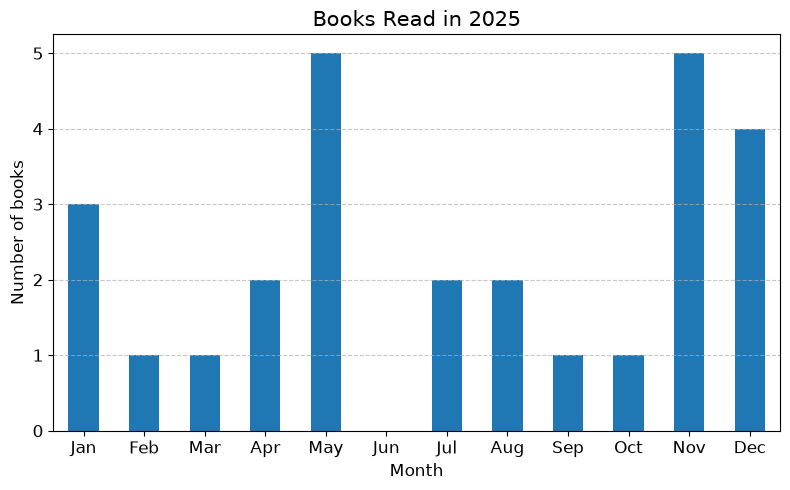

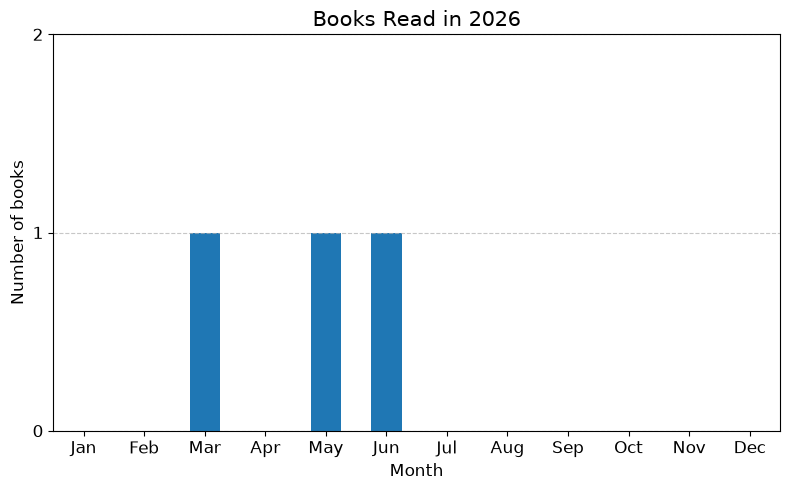

In [23]:
books_2024= readbooks[readbooks['Year Read']==2024]
books_per_month_2024 = books_2024['Month Read'].value_counts().sort_index()
#print(books_per_month_2024)
#the plot only covers from the 5th months onward since there was no books read in Jan-Apr
#creating the calendar for all 12 months
month_name =['Jan','Feb','Mar','Apr','May','Jun',
                'Jul', 'Aug', 'Sep', 'Oct','Nov','Dec']
all_months_2024 = pd.Series(0,index=range(1,13))
all_months_2024.update(books_per_month_2024)
all_months_2024.index = month_name

plt.figure(figsize=(8,5))
all_months_2024.plot(kind='bar')
plt.title('Books Read in 2024',fontsize=15)
plt.ylabel('Number of books',fontsize=12)
plt.xlabel('Month',fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(rotation=0,fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Images/booksread_2024.png')
# plt.show()

#books per month for 2025
books_2025 = readbooks[readbooks['Year Read']==2025]
books_per_month_2025 = books_2025['Month Read'].value_counts().sort_index()
#print(books_per_month_2025)

all_months_2025 = pd.Series(0,index=range(1,13))
all_months_2025.update(books_per_month_2025)
all_months_2025.index = month_name
plt.figure(figsize=(8,5))
all_months_2025.plot(kind='bar')
plt.title('Books Read in 2025',fontsize=15)
plt.ylabel('Number of books',fontsize=12)
plt.xlabel('Month',fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(rotation=0,fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Images/booksread_2025.png')
# plt.show()

#books per month for 2026
books_2026 = readbooks[readbooks['Year Read']==2026]
books_per_month_2026 = books_2026['Month Read'].value_counts().sort_index()
#print(books_per_month_2026)

all_months_2026 = pd.Series(0,index=range(1,13))
all_months_2026.update(books_per_month_2026)
all_months_2026.index = month_name

plt.figure(figsize=(8,5))
all_months_2026.plot(kind='bar')

plt.title('Books Read in 2026',fontsize=15)
plt.ylabel('Number of books',fontsize=12)
plt.xlabel('Month',fontsize=12)
plt.xticks(rotation=0,fontsize=12)
plt.yticks(range(0, int(all_months_2026.max()) + 2),fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('Images/booksread_2026.png')

# Rating Distribution
Examine the distribution of ratings across all rated books.

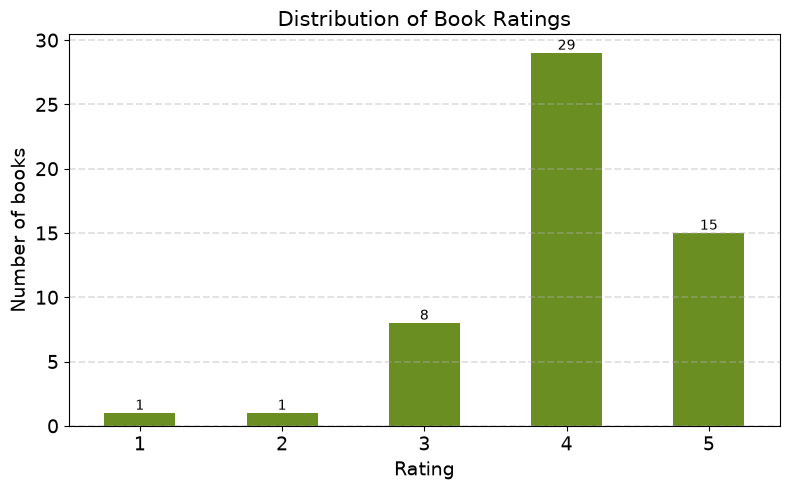

In [24]:
booksrating =ratedbooks['My Rating'].value_counts().sort_index()
#print(booksrating)
plt.figure(figsize=(8,5))
ax = booksrating.plot(kind='bar',color = ['olivedrab'])
ax.bar_label(ax.containers[0])
plt.title('Distribution of Book Ratings',fontsize=15)
plt.ylabel("Number of books",fontsize=14)
plt.xlabel('Rating',fontsize=14)
plt.xticks(rotation=0,fontsize=14)
plt.yticks(fontsize=14)
plt.grid(axis='y',linestyle='--',alpha=0.4,linewidth=1.3)
plt.tight_layout()
plt.savefig('Images/ratings.png')

# Key Findings     📊

- **Reading volume:** Reading activity remained stable between 2024 and 2025, with 28 and 27 books read respectively.
- **Pages read:** Despite similar book counts, total pages read decreased from 7,466 in 2024 to 6,508 in 2025, indicating a lower average book length.
- **Average rating:** Books received an average rating above 4 stars, suggesting generally positive reviews.
- **Book length:** Most books read were under 300 pages, despite a few long outliers.
- **Reading activity:** Reading was concentrated in specific months rather than being evenly distributed throughout the year.